In [1]:
# Import packages and functions
from SimulationSetup import *
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools

plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.title_fontsize'] = 14
plt.rcParams['legend.fontsize'] = 14

# Simulations for 2-echelon models
## Without lead times

In [2]:
c00_results = pickle.load(open(fr'PolicyResults/2ech_c0-0_cap1000_MOQ2000_sl98.0_gamma0.999.pkl', "rb"))
c00_policy = c00_results["optimal_policy"]
c00_opt_costs = c00_results["value_function"]

Results for centralised system with DC-warehouse ordering constraint
Warehouse service level: 81.00%
DC service level: 100.00%
Total system costs: 9605.579007087801


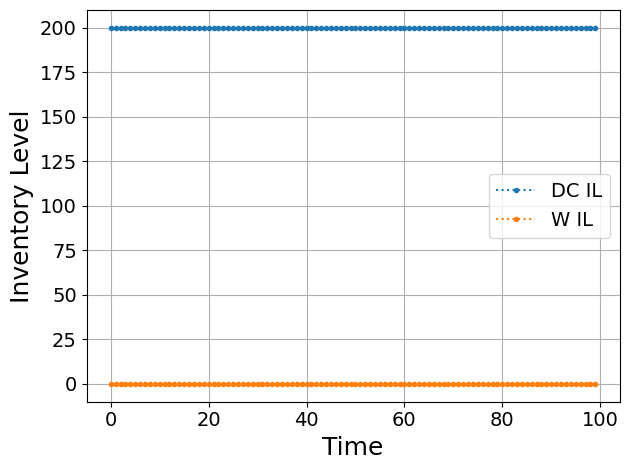

In [3]:
num_periods = 100
initial_ils = (0, 0)
gamma = 0.999
lead_times = [0, 0]
hs = [1, 0.5]
ps = [50, 25]
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
tol = 1e-7
np.random.seed(1234)
c00_simulation_results = simulate_2ech_constlead(num_periods, gamma, initial_ils, hs, ps, 
                                                 demand_dist, lead_times, c00_policy, tol)
states_seen, ILs_pre_demand, IPs_pre_demand, costs, demands, actions, total_cost = c00_simulation_results

print("Results for centralised system with DC-warehouse ordering constraint")
print(f"Warehouse service level: {sum(states_seen[i][1]+action[1] > 0 for i, action in enumerate(actions))/num_periods*100:.2f}%")
print(f"DC service level: {sum(il[0] > 0 for il in ILs_pre_demand)/num_periods*100:.2f}%")
print(f"Total system costs: {total_cost}")
plt.plot([il[0] for il in IPs_pre_demand], marker = ".", linestyle = ":", label="DC IL")
plt.plot([il[1] for il in IPs_pre_demand], marker = ".", linestyle = ":", label="W IL")
plt.xlabel("Time", fontsize = 18)
plt.ylabel("Inventory Level", fontsize = 18)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# dc_path = []
# w_path = []
# ech_w_path = []
# for i in range(num_periods):
#     dc_path.append(states_seen[i][0])
#     dc_path.append(IPs_pre_demand[i][0])
#     w_path.append(states_seen[i][1])
#     w_path.append(IPs_pre_demand[i][1])
#     ech_w_path.append(sum(states_seen[i]))
#     ech_w_path.append(sum(IPs_pre_demand[i]))

# plt.plot(np.arange(0, num_periods, 0.5), dc_path, linestyle = "-", alpha = 0.8, label = "DC IL", color = '#377eb8')
# plt.scatter(np.arange(num_periods), [il[0] for il in states_seen[:-1]], marker = ".", color = '#377eb8')
# plt.scatter(np.arange(0.5, num_periods), [il[0] for il in IPs_pre_demand], marker = "x", color = '#377eb8')
# plt.plot(np.arange(0, num_periods, 0.5), w_path, linestyle = "-", alpha = 0.8, label = "W IL", color= "orange")
# plt.scatter(np.arange(num_periods), [il[1] for il in states_seen[:-1]], marker = ".", color = "orange")
# plt.scatter(np.arange(0.5, num_periods), [il[1] for il in IPs_pre_demand], marker = "x", color = "orange")
# plt.xlabel("Time", fontsize = 18)
# plt.ylabel("Inventory Level", fontsize = 18)
# plt.legend()
# plt.grid()
# plt.tight_layout()
# plt.show()



### Comparing cost results from simulation with value iteration

Here we compare costs incurred during simulations versus value iteration. We perform 100 runs of the simulation where the length of each simulation is 100 time periods. We use a seed for reproducibility.

In [6]:
# Testing a simulation replication for a centralised system with DWOC for gamma = 0.999
nreps = 100
num_periods = 100
hs = [1, 0.5]
ps = [50, 25]
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
lead_times = [0,0]
tol = 1e-7
gamma = 0.999
il0_set = set(int(x) for x in np.linspace(-1000, 1000, 21))
ils_to_check = sorted(set(order_pair for order_pair in itertools.product(il0_set, repeat=2))) 

print("Centralised simulation:")
c00_simulation_costs = simulate_2ech_replications(c00_policy, nreps, num_periods, gamma, 
                           hs, ps, demand_dist, tol, ils_to_check, lead_times, simulate_2ech_constlead)

Centralised simulation:


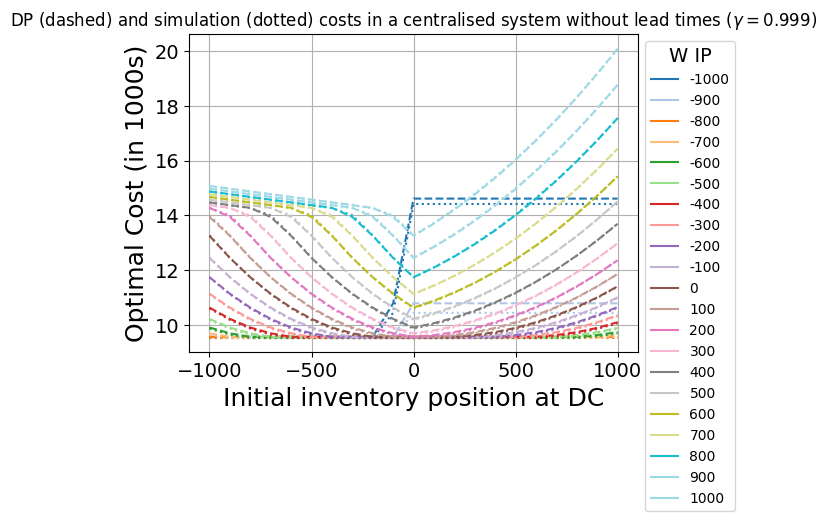

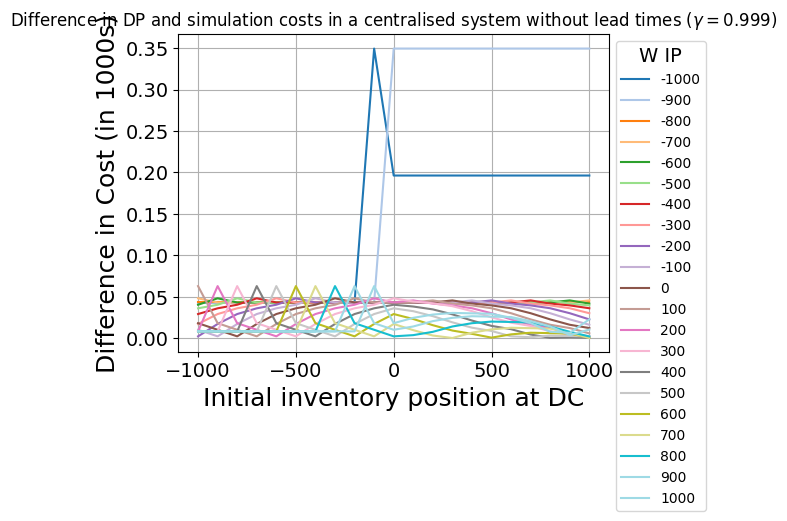

In [7]:
two_cost_plot(c00_simulation_costs, c00_opt_costs, lead_times, 2, title=fr"centralised system without lead times ($\gamma=0.999$)")
cost_diff_plot(c00_simulation_costs, c00_opt_costs, lead_times, 2, title=fr"centralised system without lead times ($\gamma=0.999$)")


## With lead times and penalty costs at warehouse

In [8]:
c11_results = pickle.load(open(fr'PolicyResults/2ech_c1-1_cap600_MOQ1300_sl98.0_gamma0.999.pkl', "rb"))
c11_policy = c11_results["optimal_policy"]
c11_opt_costs = c11_results["value_function"]
c110_results = pickle.load(open(fr'PolicyResults/2ech_c1-1-0_cap600_MOQ1300_sl98.0_gamma0.999.pkl', "rb"))
c110_policy = c110_results["optimal_policy"]
c110_opt_costs = c110_results["value_function"]

In [ ]:
# c11_policy
# c11_opt_costs

Results for centralised system with DC-warehouse ordering constraint
Warehouse service level: 90.00%
DC service level: 80.00%
Total system costs: 11095.438670137068
initial state: (0, 0, 0, 0) , action: (0, 500) , IPs before demand: (0, 500) , demand:  0
initial state: (0, 0, 0, 500) , action: (400, 0) , IPs before demand: (400, 100) , demand:  100
initial state: (-100, 100, 400, 0) , action: (100, 100) , IPs before demand: (400, 100) , demand:  100
initial state: (200, 0, 100, 100) , action: (100, 100) , IPs before demand: (400, 100) , demand:  100
initial state: (200, 0, 100, 100) , action: (100, 100) , IPs before demand: (400, 100) , demand:  100
initial state: (200, 0, 100, 100) , action: (100, 100) , IPs before demand: (400, 100) , demand:  100
initial state: (200, 0, 100, 100) , action: (100, 100) , IPs before demand: (400, 100) , demand:  100
initial state: (200, 0, 100, 100) , action: (100, 100) , IPs before demand: (400, 100) , demand:  200
initial state: (100, 0, 100, 100) , 

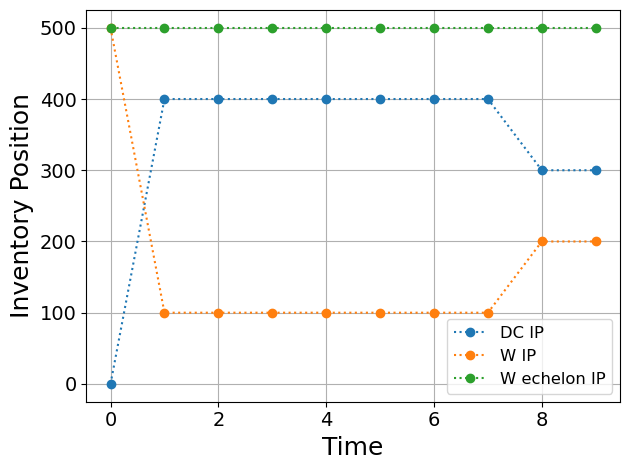

In [9]:
num_periods = 100
times = range(num_periods)
initial_ips = (0, 0, 0, 0)
gamma = 0.999
lead_times = [1, 1]
hs = [1, 0.5]
ps = [50, 25]
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
tol = 1e-7
np.random.seed(1234)
c11_simulation_results = simulate_2ech_constlead(num_periods, gamma, initial_ips, hs, ps,
                                              demand_dist, lead_times, c11_policy, tol)
states_seen, ILs_pre_demand, IPs_pre_demand, costs, demands, actions, total_cost = c11_simulation_results

print("Results for centralised system with DC-warehouse ordering constraint")
print(f"Warehouse service level: {sum(states_seen[i][1]+action[1] > 0 for i, action in enumerate(actions))/num_periods*100:.2f}%")
print(f"DC service level: {sum(il[0] > 0 for il in ILs_pre_demand)/num_periods*100:.2f}%")
print(f"Total system costs: {total_cost}")

plt.plot(times, [il[0] for il in IPs_pre_demand], marker = "o", linestyle = ":", label="DC IP")
plt.plot(times, [il[1] for il in IPs_pre_demand], marker = "o", linestyle = ":", label="W IP")
plt.plot(times, [il[1]+il[0] for il in IPs_pre_demand], marker = "o", linestyle = ":", label="W echelon IP")
plt.xlabel("Time", fontsize = 18)
plt.ylabel("Inventory Position", fontsize = 18)
plt.legend(loc="lower right", fontsize = 11.8)
plt.tight_layout()
plt.grid()

# for i in range(num_periods):
#     print("initial state:", states_seen[i], ", action:", actions[i], ", IPs before demand:", IPs_pre_demand[i], ", demand: ", demands[i])



### Comparing cost results from simulation with value iteration

Here we compare costs incurred during simulations versus value iteration. We perform 100 runs of the simulation where the length of each simulation is 100 time periods. We use a seed for reproducibility.

In [13]:
# Testing a simulation replication for a centralised system with DWOC for gamma = 0.999
nreps = 1
num_periods = 100
hs = [1, 0.5]
ps = [50, 25]
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
lead_times = [1, 1]
n_ech = 2
tol = 1e-7
gamma = 0.999
ips0_set = set(int(x) for x in np.arange(-700, 1900+1, 300))
ips_to_check = set(itertools.product(ips0_set, repeat=2)) 
states_to_check = sorted(set(state for state in c11_policy.keys() if calculate_ip(state, lead_times, n_ech) in ips_to_check))

print(ips0_set)
print("Centralised simulation:")
c11_simulation_costs = simulate_2ech_replications(c11_policy, nreps, num_periods, gamma, 
                           hs, ps, demand_dist, tol, states_to_check, lead_times, simulate_2ech_constlead)

{800, -700, 1700, 200, 1100, -400, 500, 1400, -100}
Centralised simulation:


KeyboardInterrupt: 

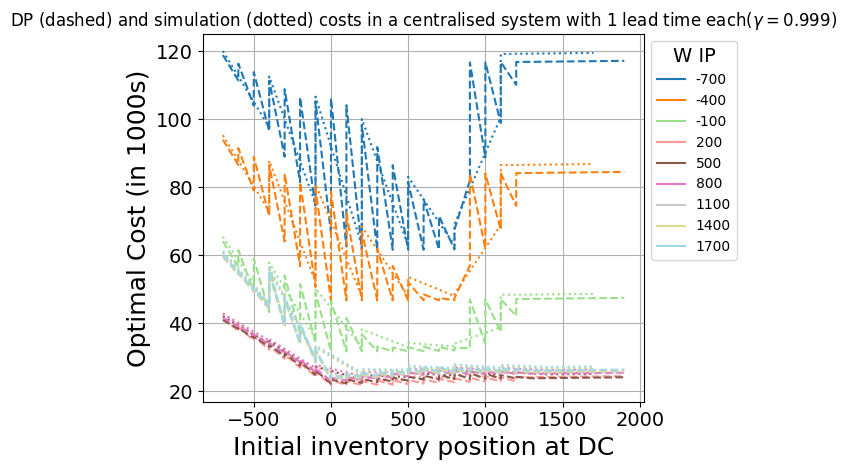

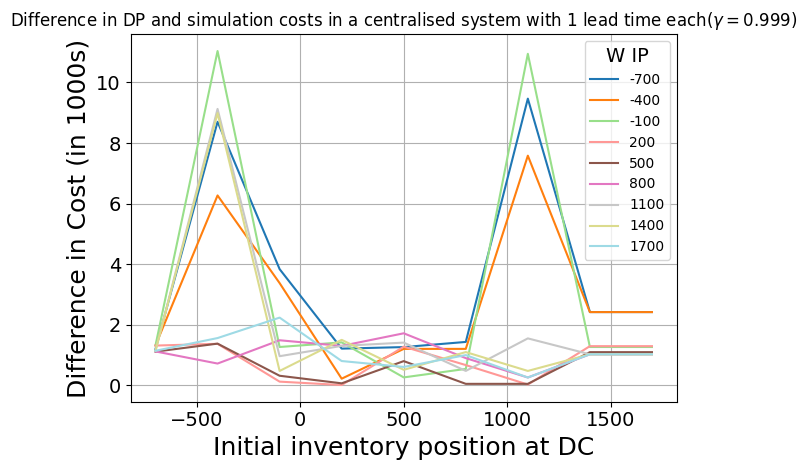

({(-700, -700, 0, 0): 101312.27007452719,
  (-700, -700, 0, 100): 96347.21010452718,
  (-700, -700, 0, 200): 91452.7878469064,
  (-700, -700, 0, 300): 86457.7878469064,
  (-700, -700, 0, 400): 81462.7878469064,
  (-700, -700, 0, 500): 76467.7878469064,
  (-700, -700, 0, 600): 71472.7878469064,
  (-700, -700, 0, 700): 66477.7878469064,
  (-700, -700, 0, 800): 62501.7678469064,
  (-700, -700, 0, 900): 61582.687846906396,
  (-700, -700, 0, 1000): 61632.687846906396,
  (-700, -700, 0, 1100): 61682.687846906396,
  (-700, -700, 0, 1200): 61782.63784690639,
  (-700, -700, 0, 1300): 61906.559825937635,
  (-700, -700, 100, 0): 95319.25808052719,
  (-700, -700, 100, 100): 90368.32565300303,
  (-700, -700, 100, 200): 85463.77784690639,
  (-700, -700, 100, 300): 80468.77784690639,
  (-700, -700, 100, 400): 75473.77784690639,
  (-700, -700, 100, 500): 70478.77784690639,
  (-700, -700, 100, 600): 65483.77784690639,
  (-700, -700, 100, 700): 60692.573846906394,
  (-700, -700, 100, 800): 57327.9418469

In [ ]:
two_cost_plot(c11_opt_costs, c11_simulation_costs, lead_times, n_ech, title=fr"centralised system with 1 lead time each($\gamma=0.999$)")
cost_diff_plot(c11_opt_costs, c11_simulation_costs, lead_times, n_ech, title=fr"centralised system with 1 lead time each($\gamma=0.999$)")

